In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

In [27]:
url = 'https://raw.githubusercontent.com/hjhuney/Data/master/AmesHousing/train.csv'

In [28]:
df=pd.read_csv(url)

# 1.Data Inspection

In [29]:
print(f"Data Shape: {df.shape}")

Data Shape: (1460, 81)


In [30]:
numeric_dtypes = df.select_dtypes(exclude="str")
string_dtypes = df.select_dtypes(include="str")

numeric_columns = pd.DataFrame({
    "Numeric" : numeric_dtypes.columns
}).reset_index(drop=True)

categorical_columns = pd.DataFrame({
    "String" : string_dtypes.columns
}).reset_index(drop=True)


In [31]:
null_values = df.isnull().sum()

null_values = null_values[ null_values > 0 ]

null_percentage =( ( null_values / df.shape[0] ) * 100 ).round(2)


null_data = pd.DataFrame({
    "Columns" : null_values.index,
    "Null %" : null_percentage
}).sort_values("Null %" , ascending=False).reset_index(drop=True)

null_data

,Columns,Null %
0,PoolQC,99.52
1,MiscFeature,96.30
2,Alley,93.77
3,Fence,80.75
4,MasVnrType,59.73
5,FireplaceQu,47.26
6,LotFrontage,17.74
7,GarageType,5.55
8,GarageYrBlt,5.55
9,GarageFinish,5.55


# 2.Target Variable Analysis (SalePrice)

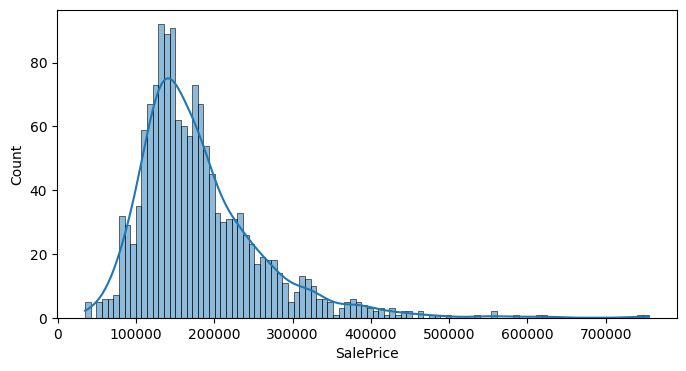

In [32]:
plt.figure(figsize=(8,4))
sns.histplot(df["SalePrice"] , bins=100 , kde=True)
plt.show()

sale_price_log = np.log1p(df["SalePrice"])


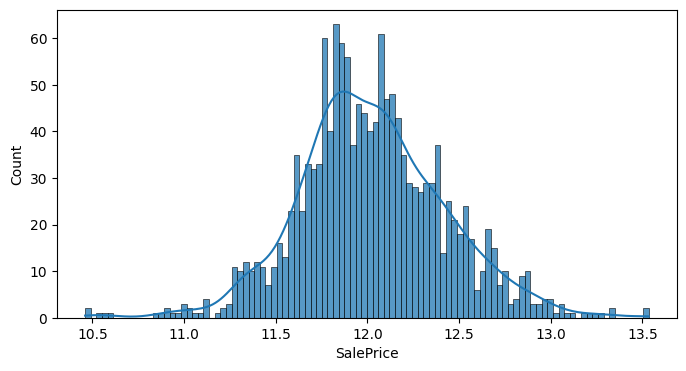

In [33]:
sale_price_log = np.log1p(df["SalePrice"])
plt.figure(figsize=(8,4))
sns.histplot(sale_price_log , bins=100 , kde=True , alpha=0.75)
plt.show()


# sale_price_log = np.log1p(df["SalePrice"])

# plt.figure(figsize=(10,5))

# sns.histplot(
#     sale_price_log,
#     bins=50,
#     kde=True,
#     color="steelblue",
#     edgecolor="black"
# )

# plt.axvline(
#     sale_price_log.mean(),
#     color="red",
#     linestyle="--",
#     linewidth=2,
#     label=f"Mean = {sale_price_log.mean():.2f}"
# )

# plt.axvline(
#     sale_price_log.median(),
#     color="green",
#     linestyle="-.",
#     linewidth=2,
#     label=f"Median = {sale_price_log.median():.2f}"
# )

# plt.title("Log Transformed SalePrice Distribution")
# plt.xlabel("Log(SalePrice)")
# plt.ylabel("Frequency")

# plt.legend()
# plt.grid(alpha=0.3)

# plt.show()

In [34]:
df.drop("Id" , inplace=True , axis=1)

In [35]:
mean_of_cols = df.describe().loc["mean"]
median_of_cols = df.describe().loc["50%"]

diff = (mean_of_cols - median_of_cols) / mean_of_cols

right_skewed_cols = diff[diff > 0.1].index
left_skewed_cols = diff[diff < -0.1].index
symmetric_cols = diff[(diff >= -0.1) & (diff <= 0.1)].index

print("Right Skewed:", list(right_skewed_cols))
print("Left Skewed :", list(left_skewed_cols))
print("Symmetric   :", list(symmetric_cols))


Right Skewed: ['MSSubClass', 'OverallCond', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', '2ndFlrSF', 'LowQualFinSF', 'BsmtFullBath', 'BsmtHalfBath', 'HalfBath', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal']
Left Skewed : ['FullBath', 'Fireplaces', 'GarageCars']
Symmetric   : ['LotFrontage', 'LotArea', 'OverallQual', 'YearBuilt', 'YearRemodAdd', 'TotalBsmtSF', '1stFlrSF', 'GrLivArea', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'GarageYrBlt', 'GarageArea', 'MoSold', 'YrSold', 'SalePrice']


# 3. Numerical Features EDA + Statistical Inference

In [36]:
num_cols = df.select_dtypes(include=np.number)


In [ ]:
target_corr = num_cols.corr()["SalePrice"]

target_corr = target_corr[ (target_corr > 0.5 ) | (target_corr < -0.5) ]
target_corr = target_corr.drop("SalePrice")
cols = np.array(target_corr.index)
cols

array(['OverallQual', 'YearBuilt', 'YearRemodAdd', 'TotalBsmtSF',
       '1stFlrSF', 'GrLivArea', 'FullBath', 'TotRmsAbvGrd', 'GarageCars',
       'GarageArea'], dtype=object)

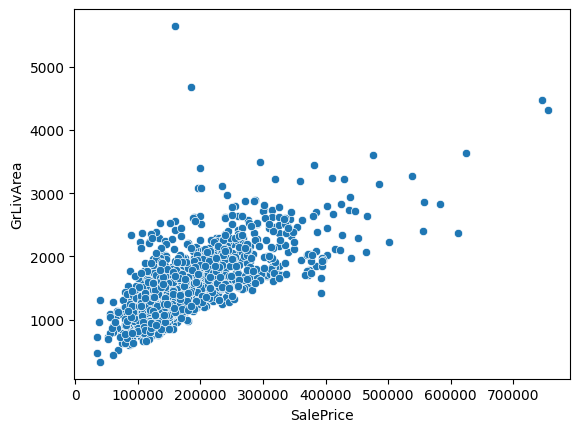

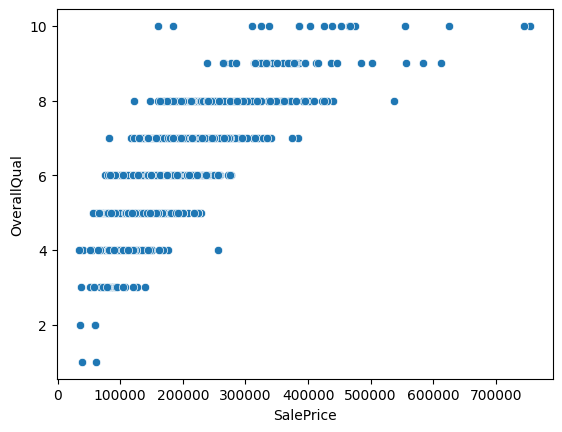

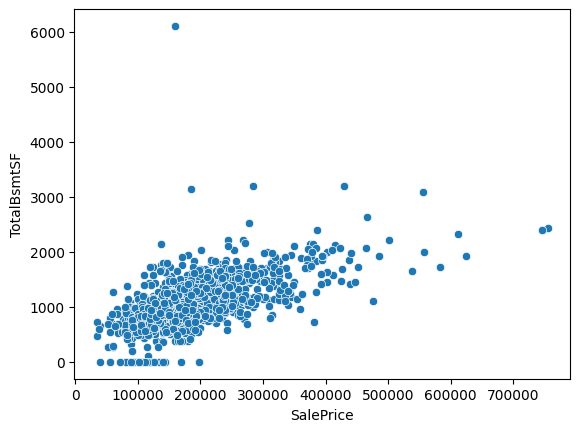

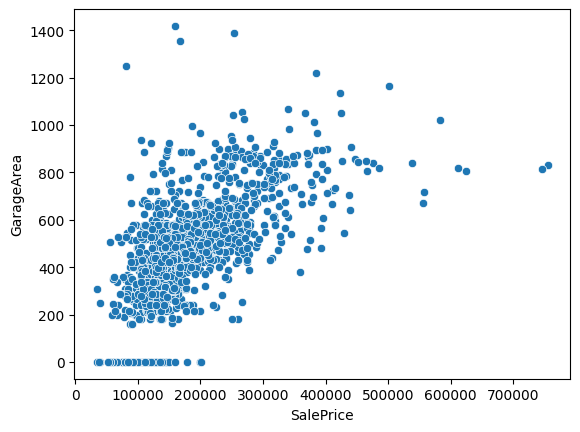

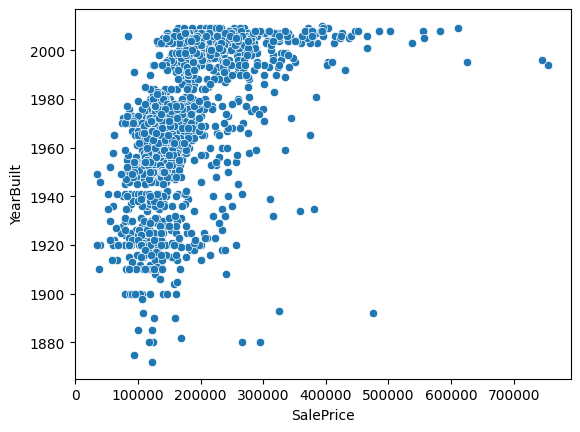

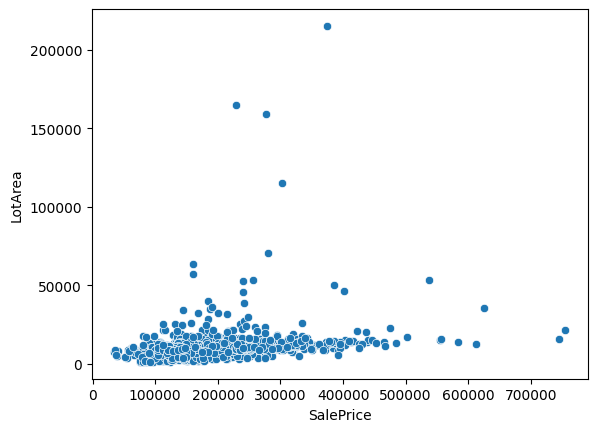

In [67]:
for col in cols:
    sns.scatterplot( x=df["SalePrice"] , y=df[col])
    plt.show()

In [39]:
df.head(30)

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
5,50,RL,85.0,14115,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Mitchel,Norm,Norm,1Fam,1.5Fin,5,5,1993,1995,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,Wood,Gd,TA,No,GLQ,732,Unf,0,64,796,GasA,Ex,Y,SBrkr,796,566,0,1362,1,0,1,1,1,1,TA,5,Typ,0,NaN,Attchd,1993.0,Unf,2,480,TA,TA,Y,40,30,0,320,0,0,NaN,MnPrv,Shed,700,10,2009,WD,Normal,143000
6,20,RL,75.0,10084,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Somerst,Norm,Norm,1Fam,1Story,8,5,2004,2005,Gable,CompShg,VinylSd,VinylSd,Stone,186.0,Gd,TA,PConc,Ex,TA,Av,GLQ,1369,Unf,0,317,1686,GasA,Ex,Y,SBrkr,1694,0,0,1694,1,0,2,0,3,1,Gd,7,Typ,1,Gd,Attchd,2004.0,RFn,2,636,TA,TA,Y,255,57,0,0,0,0,NaN,NaN,NaN,0,8,2007,WD,Normal,307000
7,60,RL,NaN,10382,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NWAmes,PosN,Norm,1Fam,2Story,7,6,1973,1973,Gable,CompShg,HdBoard,HdBoard,Stone,240.0,TA,TA,CBlock,Gd,TA,Mn,ALQ,859,BLQ,32,216,1107,GasA,Ex,Y,SBrkr,1107,983,0,2090,1,0,2,1,3,1,TA,7,Typ,2,TA,Attchd,1973.0,RFn,2,484,TA,TA,Y,235,204,228,0,0,0,NaN,NaN,Shed,350,11,2009,WD,Normal,200000
8,50,RM,51.0,6120,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,OldTown,Artery,Norm,1Fam,1.5Fin,7,5,1931,1950,Gable,CompShg,BrkFace,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,TA,No,Unf,0,Unf,0,952,952,GasA,Gd,Y,FuseF,1022,752,0,1774,0,0,2,0,2,2,TA,8,Min1,2,TA,Detchd,1931.0,Unf,2,468,Fa,TA,Y,90,0,205,0,0,0,NaN,NaN,NaN,0,4,2008,WD,Abnorml,129900
9,190,RL,50.0,7420,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,BrkSide,Artery,Artery,2fmCon,1.5Unf,5,6,1939,1950,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,BrkTil,TA,TA,No,GLQ,851,Unf,0,140,991,GasA,Ex,Y,SBrkr,1077,0,0,1077,1,

In [40]:
print(f"Shape of Data : {df.shape}")

Shape of Data : (1460, 80)


#### Columns Selection for Encoding And Dropping

In [41]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler


# Feature Engineering

df["house_age"] = df["YrSold"] - df["YearBuilt"]

df.drop(["YrSold", "YearBuilt", "Id"], axis=1, inplace=True)


# Train Test Split

X = df.drop("SalePrice", axis=1)
y = df["SalePrice"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)


# Column Selection

cat_cols = X_train.select_dtypes(include=["object", "category"]).columns

num_cols = X_train.select_dtypes(exclude=["object", "category"]).columns


# Low & High Cardinality

ohe_cols = cat_cols[X_train[cat_cols].nunique() < 5]

freq_cols = cat_cols[X_train[cat_cols].nunique() >= 5]


# Frequency Encoding

for col in freq_cols:

    freq_map = X_train[col].value_counts().to_dict()

    X_train[col] = X_train[col].map(freq_map)

    X_test[col] = X_test[col].map(freq_map)

    # unseen category in test
    X_test[col] = X_test[col].fillna(0)


# Numerical Columns
# (frequency encoded columns are now numeric)

num_pipeline_cols = list(num_cols) + list(freq_cols)


# Numerical Pipeline

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])


# Categorical Pipeline

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])


# Column Transformer

preprocessor = ColumnTransformer([

    ("num", num_pipeline, num_pipeline_cols),

    ("cat", cat_pipeline, ohe_cols)

])


# Transform

X_train = preprocessor.fit_transform(X_train)

X_test = preprocessor.transform(X_test)

KeyError: "['Id'] not found in axis"